# Using Machine Learning techniques to predict a stroke

## Imports

In [586]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report
from sklearn.base import clone
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.pipeline import Pipeline

## Load in data, basic data information

In [587]:
path = kagglehub.dataset_download("najmilfuad/oral-cancer-data-set")

file_path = os.path.join(path, "oral_cancer_prediction_dataset.csv")
df = pd.read_csv(file_path)

df.head()

,ID,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,...,Difficulty Swallowing,White or Red Patches in Mouth,Tumor Size (cm),Cancer Stage,Treatment Type,"Survival Rate (5-Year, %)",Cost of Treatment (USD),Economic Burden (Lost Workdays per Year),Early Diagnosis,Oral Cancer (Diagnosis)
0,1,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,No,No
1,2,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,...,No,No,1.782186,1,No Treatment,83.340103,77772.50,177,No,Yes
2,3,UK,37,Female,No,Yes,No,No,Yes,Yes,...,No,Yes,3.523895,2,Surgery,63.222871,101164.50,130,Yes,Yes
3,4,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,...,No,No,0.000000,0,No Treatment,100.000000,0.00,0,Yes,No
4,5,South Africa,68,Male,No,No,No,No,No,Yes,...,No,No,2.834789,3,No Treatment,44.293199,45354.75,52,No,Yes


In [588]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 84922 entries, 0 to 84921
Data columns (total 25 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   ID                                        84922 non-null  int64  
 1   Country                                   84922 non-null  str    
 2   Age                                       84922 non-null  int64  
 3   Gender                                    84922 non-null  str    
 4   Tobacco Use                               84922 non-null  str    
 5   Alcohol Consumption                       84922 non-null  str    
 6   HPV Infection                             84922 non-null  str    
 7   Betel Quid Use                            84922 non-null  str    
 8   Chronic Sun Exposure                      84922 non-null  str    
 9   Poor Oral Hygiene                         84922 non-null  str    
 10  Diet (Fruits & Vegetables Intake)         849

## Data cleaning

In [589]:
df.columns

Index(['ID', 'Country', 'Age', 'Gender', 'Tobacco Use', 'Alcohol Consumption',
       'HPV Infection', 'Betel Quid Use', 'Chronic Sun Exposure',
       'Poor Oral Hygiene', 'Diet (Fruits & Vegetables Intake)',
       'Family History of Cancer', 'Compromised Immune System', 'Oral Lesions',
       'Unexplained Bleeding', 'Difficulty Swallowing',
       'White or Red Patches in Mouth', 'Tumor Size (cm)', 'Cancer Stage',
       'Treatment Type', 'Survival Rate (5-Year, %)',
       'Cost of Treatment (USD)', 'Economic Burden (Lost Workdays per Year)',
       'Early Diagnosis', 'Oral Cancer (Diagnosis)'],
      dtype='str')

### Checking data for unique values

Before modifying the data to be fit for training we should check how many unique values each feature can have, so that we can determine how to represent it (eg. use 0 and 1 for yes-no columns or one-hot encoding for those with more posiible values).

In [590]:
for column in df.columns:
    print(f"{column} values: {df[column].unique()}")

id values: [ 9046 51676 31112 ... 19723 37544 44679]
gender values: <StringArray>
['Male', 'Female', 'Other']
Length: 3, dtype: str
age values: [6.70e+01 6.10e+01 8.00e+01 4.90e+01 7.90e+01 8.10e+01 7.40e+01 6.90e+01
 5.90e+01 7.80e+01 5.40e+01 5.00e+01 6.40e+01 7.50e+01 6.00e+01 5.70e+01
 7.10e+01 5.20e+01 8.20e+01 6.50e+01 5.80e+01 4.20e+01 4.80e+01 7.20e+01
 6.30e+01 7.60e+01 3.90e+01 7.70e+01 7.30e+01 5.60e+01 4.50e+01 7.00e+01
 6.60e+01 5.10e+01 4.30e+01 6.80e+01 4.70e+01 5.30e+01 3.80e+01 5.50e+01
 1.32e+00 4.60e+01 3.20e+01 1.40e+01 3.00e+00 8.00e+00 3.70e+01 4.00e+01
 3.50e+01 2.00e+01 4.40e+01 2.50e+01 2.70e+01 2.30e+01 1.70e+01 1.30e+01
 4.00e+00 1.60e+01 2.20e+01 3.00e+01 2.90e+01 1.10e+01 2.10e+01 1.80e+01
 3.30e+01 2.40e+01 3.40e+01 3.60e+01 6.40e-01 4.10e+01 8.80e-01 5.00e+00
 2.60e+01 3.10e+01 7.00e+00 1.20e+01 6.20e+01 2.00e+00 9.00e+00 1.50e+01
 2.80e+01 1.00e+01 1.80e+00 3.20e-01 1.08e+00 1.90e+01 6.00e+00 1.16e+00
 1.00e+00 1.40e+00 1.72e+00 2.40e-01 1.64e+00 1.56e+0

### Dropping columns
In this stage we get rid of features that are synonymous with cancer (eg. Tumor Size, Cancer Stage), and ID column, since it carries no useful information.

In [591]:
df = df.drop(df.columns[17:-2], axis="columns")
df = df.drop(df.columns[0], axis="columns")
df.head()

,Country,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Diet (Fruits & Vegetables Intake),Family History of Cancer,Compromised Immune System,Oral Lesions,Unexplained Bleeding,Difficulty Swallowing,White or Red Patches in Mouth,Early Diagnosis,Oral Cancer (Diagnosis)
0,Italy,36,Female,Yes,Yes,Yes,No,No,Yes,Low,No,No,No,No,No,No,No,No
1,Japan,64,Male,Yes,Yes,Yes,No,Yes,Yes,High,No,No,No,Yes,No,No,No,Yes
2,UK,37,Female,No,Yes,No,No,Yes,Yes,Moderate,No,No,No,No,No,Yes,Yes,Yes
3,Sri Lanka,55,Male,Yes,Yes,No,Yes,No,Yes,Moderate,No,No,Yes,No,No,No,Yes,No
4,South Africa,68,Male,No,No,No,No,No,Yes,High,No,No,No,No,No,No,No,Yes


### Checking data for unique values

Before modifying the data to be fit for training we should check how many unique values each feature can have, so that we can determine how to represent it (eg. use 0 and 1 for yes-no columns or one-hot encoding for those with more posiible values).

In [483]:
for column in df.columns:
    print(f"{column} values: {df[column].unique()}")

Country values: <StringArray>
[       'Italy',        'Japan',           'UK',    'Sri Lanka',
 'South Africa',       'Taiwan',          'USA',      'Germany',
       'France',    'Australia',       'Brazil',     'Pakistan',
        'Kenya',       'Russia',      'Nigeria',        'Egypt',
        'India']
Length: 17, dtype: str
Age values: [ 36  64  37  55  68  70  41  53  62  50  65  34  56  59  43  63  44  71
  51  47  58  57  54  67  31  66  48  61  46  49  60  74  42  73  69  35
  52  39  40  45  28  38  33  75  78  72  76  29  80  32  26  77  30  79
  82  89  23  22  81  18  24  83  25  86  21  87  19  27  17  85  84  20
  88  15  93  92  94  90  96  16  91 101  98]
Gender values: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Tobacco Use values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Alcohol Consumption values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
HPV Infection values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Betel Quid Use values: <String

### Checking for NaN values

We check if there are any values missing from the dataset.
- `df.isna()` – returns a DataFrame of True/False values (True if the value in the original DataFrame is NaN, False otherwise)  
- `df.isna().any()` – for each column, checks if it contains at least one True value  
- `df.isna().any().any()` – returns True if there is **at least one NaN** in the original DataFrame, False otherwise

In [592]:
df.isna().any().any()

np.False_

### Modifying the data

In [593]:
df["bmi"] = df["bmi"].fillna(df.groupby("gender")["bmi"].transform("mean"))
df

,Age,Gender,Tobacco Use,Alcohol Consumption,HPV Infection,Betel Quid Use,Chronic Sun Exposure,Poor Oral Hygiene,Family History of Cancer,Compromised Immune System,...,Country_Pakistan,Country_Russia,Country_South Africa,Country_Sri Lanka,Country_Taiwan,Country_UK,Country_USA,Diet (Fruits & Vegetables Intake)_High,Diet (Fruits & Vegetables Intake)_Low,Diet (Fruits & Vegetables Intake)_Moderate
0,36,0,1,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,1,0


### Modifying the data

In [594]:
# Binary to 1/0
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

for column in df.columns:
    if np.isin("Yes", df[column].unique()):
        df[column] = df[column].map({"Yes": 1, "No": 0})

# One-Hot Encoding
df = pd.get_dummies(df, columns=["Country", "Diet (Fruits & Vegetables Intake)"])

# Convert all bool columns from OHE to int
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,id,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,gender_Female,gender_Male,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
1,64,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,37,0,0,1,0,0,1,1,0,0,...,0,0,0,0,0,1,0,0,0,1
3,55,1,1,1,0,1,0,1,0,0,...,0,0,0,1,0,0,0,0,0,1
4,68,1,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,1,0,0


In [595]:
# Move label to the rightmost side of the dataframe
cols = [c for c in df.columns if c != "Oral Cancer (Diagnosis)"] + ["Oral Cancer (Diagnosis)"]
df = df[cols]

### Renaming the columns

In this step we standardize the naming convention of features in the dataframe.

In [596]:
def get_renamed_column(name):
    # Remove parentheses and their contents
    name = name[:name.index("(")] + name[name.index(")") + 1:] if "(" in name else name
    name = name.strip()
    name = name.lower()
    name = name.replace(" ", "_")
    name = name.replace("__", "_")

    return name


def get_rename_dict(column_names):
    rename_dict = {}
    for name in column_names:
        rename_dict[name] = get_renamed_column(name)

    return rename_dict

In [597]:
df = df.rename(columns=get_rename_dict(df.columns))
df.head()

,age,gender,tobacco_use,alcohol_consumption,hpv_infection,betel_quid_use,chronic_sun_exposure,poor_oral_hygiene,family_history_of_cancer,compromised_immune_system,...,country_russia,country_south_africa,country_sri_lanka,country_taiwan,country_uk,country_usa,diet_high,diet_low,diet_moderate,oral_cancer
0,36,0,1,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
1,64,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,1
2,37,0,0,1,0,0,1,1,0,0,...,0,0,0,0,1,0,0,0,1,1
3,55,1,1,1,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0,1,0
4,68,1,0,0,0,0,0,1,0,0,...,0,1,0,0,0,0,1,0,0,1


### Check for duplicates

In [598]:
any(df.duplicated())

True

There are only unique records in the dataset already, we may proceed.

### Check for class imbalance

Ideally here should be a similar number of records in each class.

In [599]:
df[df.columns[-1]].sum() / df[df.columns[-1]].size

np.float64(0.4986811426956501)

Since stroke was confirmed only in 5% of patients we will use a few different techniques deal with the imbalance.

## Preparing the train and test sets

### Train-test split

In [600]:
print(df.columns)

Index(['age', 'gender', 'tobacco_use', 'alcohol_consumption', 'hpv_infection',
       'betel_quid_use', 'chronic_sun_exposure', 'poor_oral_hygiene',
       'family_history_of_cancer', 'compromised_immune_system', 'oral_lesions',
       'unexplained_bleeding', 'difficulty_swallowing',
       'white_or_red_patches_in_mouth', 'early_diagnosis', 'country_australia',
       'country_brazil', 'country_egypt', 'country_france', 'country_germany',
       'country_india', 'country_italy', 'country_japan', 'country_kenya',
       'country_nigeria', 'country_pakistan', 'country_russia',
       'country_south_africa', 'country_sri_lanka', 'country_taiwan',
       'country_uk', 'country_usa', 'diet_high', 'diet_low', 'diet_moderate',
       'oral_cancer'],
      dtype='str')


In [601]:
columns_to_drop = ["id", "ever_married", "gender_female", "gender_male", "gender_other", "work_type_govt_job", "work_type_never_worked",
       "work_type_private", "work_type_self-employed", "work_type_children"]
df = df.drop(columns=columns_to_drop)

Index(['age', 'gender', 'tobacco_use', 'alcohol_consumption', 'hpv_infection',
       'betel_quid_use', 'chronic_sun_exposure', 'poor_oral_hygiene',
       'family_history_of_cancer', 'compromised_immune_system', 'oral_lesions',
       'unexplained_bleeding', 'difficulty_swallowing',
       'white_or_red_patches_in_mouth', 'early_diagnosis', 'diet_high',
       'diet_low', 'diet_moderate', 'oral_cancer'],
      dtype='str')

In [602]:
X = df.drop(columns=[df.columns[-1]]) 
y = df[df.columns[-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Data visualization

### Correlation matrix

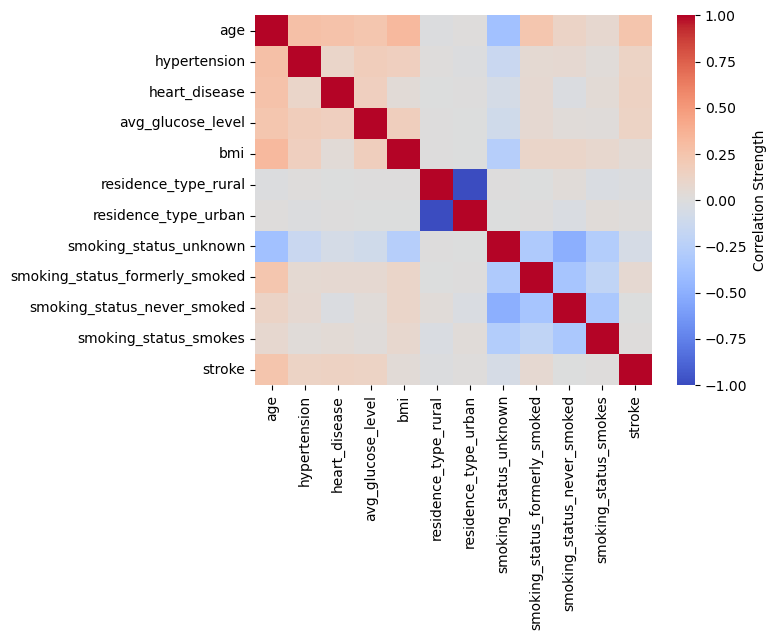

In [603]:
corr = df.corr(numeric_only=True)
ax = sns.heatmap(corr, cmap="coolwarm", vmin=-1, vmax=1, cbar=True)

cbar = ax.collections[0].colorbar
cbar.set_label("Correlation Strength")

plt.show()

## Create models

### Random Forests

In [604]:
random_forest_models = {
    "RandomForest_100_5": RandomForestClassifier(
        n_estimators=100,
        max_depth=5
    ),
    "RandomForest_50_5": RandomForestClassifier(
        n_estimators=50,
        max_depth=5
    ),
    "RandomForest_50_10": RandomForestClassifier(
        n_estimators=50,
        max_depth=10
    ),
    "RandomForest_500_3": RandomForestClassifier(
        n_estimators=500,
        max_depth=3
    ),
    "RandomForest_200_10": RandomForestClassifier(
        n_estimators=200,
        max_depth=10
    ),
    "RandomForest_300_7": RandomForestClassifier(
        n_estimators=300,
        max_depth=7
    ),
}

### XGBoost

In [605]:
xgboost_models = {
    "XGBoost_100_5_10": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        scale_pos_weight=10
    ),
    "XGBoost_50_5_10": XGBClassifier(
        n_estimators=50,
        learning_rate=0.2,
        max_depth=5,
        scale_pos_weight=10
    ),
    "XGBoost_100_10_5": XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=10,
        scale_pos_weight=5
    ),
    "XGBoost_150_7_10": XGBClassifier(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=7,
        scale_pos_weight=10
    ),
    "XGBoost_80_15_5": XGBClassifier(
        n_estimators=80,
        learning_rate=0.3,
        max_depth=15,
        scale_pos_weight=5
    ),
    "XGBoost_200_8_8": XGBClassifier(
        n_estimators=200,
        learning_rate=0.02,
        max_depth=8,
        scale_pos_weight=8
    )
}

### Neural Networks

In [606]:
input_shape = X_train.shape[1]

neural_networks_models = {
    "NN_64_32_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_32_32_32_1": Sequential([
        Dense(32, activation="sigmoid", input_shape=(input_shape,)),
        Dense(32, activation="sigmoid"),
        Dense(32, activation="sigmoid"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_64_64_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(64, activation="tanh"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_128_64_64_1": Sequential([
        Dense(128, activation="relu", input_shape=(input_shape,)),
        Dense(64, activation="relu"),
        Dense(64, activation="relu"),
        Dense(1, activation="sigmoid")
    ]),
    "NN_64_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(1, activation="sigmoid")
    ]),
    "NN_64_32_64_1": Sequential([
        Dense(64, activation="relu", input_shape=(input_shape,)),
        Dense(32, activation="tanh"),
        Dense(64, activation="tanh"),
        Dense(1, activation="sigmoid")
    ]),
}

c:\Users\Dell\anaconda\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Train models

#### Cross-validation pipeline

In [607]:
def validate_models(models, X, y):
    results = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        scores = cross_validate(pipeline, X, y, cv=5, scoring=["precision", "recall", "f1"])
        results[name] = {
            "precision": scores["test_precision"].mean(),
            "recall": scores["test_recall"].mean(),
            "f1": scores["test_f1"].mean(),
        }

    return results

#### Training pipeline

In [608]:
def train_models(models, X, y):

    trained_models = {}

    for name, model in models.items():
        pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("model", model)
        ])

        trained_pipeline = pipeline.fit(X, y)
        trained_models[name] = trained_pipeline

    return trained_models


##### SMOTE + Random Forest

In [609]:
results = validate_models(random_forest_models, X_train, y_train)
for name, result in results.items():
    print(f"{name}: {result}\n")

RandomForest_100_5: {'precision': np.float64(0.11696661773136127), 'recall': np.float64(0.7645803698435278), 'f1': np.float64(0.20282828686269125)}

RandomForest_50_5: {'precision': np.float64(0.11854899975696083), 'recall': np.float64(0.7698435277382647), 'f1': np.float64(0.20538202813545342)}

RandomForest_50_10: {'precision': np.float64(0.12216880734988642), 'recall': np.float64(0.45960170697012803), 'f1': np.float64(0.1926735785719281)}

RandomForest_500_3: {'precision': np.float64(0.11087815906732472), 'recall': np.float64(0.82375533428165), 'f1': np.float64(0.19538426520786453)}

RandomForest_200_10: {'precision': np.float64(0.122430609695905), 'recall': np.float64(0.44366998577524897), 'f1': np.float64(0.19170427068179574)}

RandomForest_300_7: {'precision': np.float64(0.12287480061045444), 'recall': np.float64(0.6732574679943101), 'f1': np.float64(0.20765250564835736)}



In [610]:
trained_models = train_models(random_forest_models, X_train, y_train)

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"{name} Accuracy: {accuracy}")
    print(f"{name} Precision: {precision}")
    print(f"{name} Recall: {recall}")
    print(f"{name} F1: {f1}\n")

RandomForest_100_5 Accuracy: 0.723091976516634
RandomForest_100_5 Precision: 0.1492063492063492
RandomForest_100_5 Recall: 0.7580645161290323
RandomForest_100_5 F1: 0.2493368700265252

RandomForest_50_5 Accuracy: 0.7455968688845401
RandomForest_50_5 Precision: 0.16095890410958905
RandomForest_50_5 Recall: 0.7580645161290323
RandomForest_50_5 F1: 0.2655367231638418

RandomForest_50_10 Accuracy: 0.8189823874755382
RandomForest_50_10 Precision: 0.1711229946524064
RandomForest_50_10 Recall: 0.5161290322580645
RandomForest_50_10 F1: 0.2570281124497992

RandomForest_500_3 Accuracy: 0.7240704500978473
RandomForest_500_3 Precision: 0.15625
RandomForest_500_3 Recall: 0.8064516129032258
RandomForest_500_3 F1: 0.2617801047120419

RandomForest_200_10 Accuracy: 0.8317025440313112
RandomForest_200_10 Precision: 0.1839080459770115
RandomForest_200_10 Recall: 0.5161290322580645
RandomForest_200_10 F1: 0.2711864406779661

RandomForest_300_7 Accuracy: 0.776908023483366
RandomForest_300_7 Precision: 0.16

##### SMOTE + XGBoost

In [611]:
results = validate_models(xgboost_models, X_train, y_train)
for name, result in results.items():
    print(f"{name}: {result}\n")

XGBoost_100_5_10: {'precision': np.float64(0.09667030188967776), 'recall': np.float64(0.7059743954480796), 'f1': np.float64(0.17002562482732592)}

XGBoost_50_5_10: {'precision': np.float64(0.09213952992975677), 'recall': np.float64(0.6520625889046942), 'f1': np.float64(0.1613852303713042)}

XGBoost_100_10_5: {'precision': np.float64(0.11441350531296354), 'recall': np.float64(0.40113798008534846), 'f1': np.float64(0.17788747625502865)}

XGBoost_150_7_10: {'precision': np.float64(0.0964371067059766), 'recall': np.float64(0.6044096728307254), 'f1': np.float64(0.16628138925419328)}

XGBoost_80_15_5: {'precision': np.float64(0.10131259615130583), 'recall': np.float64(0.25149359886201994), 'f1': np.float64(0.1441769736682718)}

XGBoost_200_8_8: {'precision': np.float64(0.0963564501087878), 'recall': np.float64(0.6735419630156472), 'f1': np.float64(0.16851271353084113)}



In [612]:
trained_models = train_models(xgboost_models, X_train, y_train)

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"{name} Accuracy: {accuracy}")
    print(f"{name} Precision: {precision}")
    print(f"{name} Recall: {recall}")
    print(f"{name} F1: {f1}\n")

XGBoost_100_5_10 Accuracy: 0.6604696673189824
XGBoost_100_5_10 Precision: 0.11590296495956873
XGBoost_100_5_10 Recall: 0.6935483870967742
XGBoost_100_5_10 F1: 0.19861431870669746

XGBoost_50_5_10 Accuracy: 0.6565557729941291
XGBoost_50_5_10 Precision: 0.11671087533156499
XGBoost_50_5_10 Recall: 0.7096774193548387
XGBoost_50_5_10 F1: 0.20045558086560364

XGBoost_100_10_5 Accuracy: 0.8336594911937377
XGBoost_100_10_5 Precision: 0.17857142857142858
XGBoost_100_10_5 Recall: 0.4838709677419355
XGBoost_100_10_5 F1: 0.2608695652173913

XGBoost_150_7_10 Accuracy: 0.700587084148728
XGBoost_150_7_10 Precision: 0.12576687116564417
XGBoost_150_7_10 Recall: 0.6612903225806451
XGBoost_150_7_10 F1: 0.211340206185567

XGBoost_80_15_5 Accuracy: 0.8620352250489237
XGBoost_80_15_5 Precision: 0.1308411214953271
XGBoost_80_15_5 Recall: 0.22580645161290322
XGBoost_80_15_5 F1: 0.16568047337278108

XGBoost_200_8_8 Accuracy: 0.6741682974559687
XGBoost_200_8_8 Precision: 0.12672176308539945
XGBoost_200_8_8 Reca

### Using class weight to deal with the imbalance

In [613]:
ensemble_set = pd.concat((X_train.copy(), y_train.copy()), axis="columns")

# Divide the ensemble set by the label
ensemble_class_0 = ensemble_set[ensemble_set[ensemble_set.columns[-1]] == 0]
ensemble_class_1 = ensemble_set[ensemble_set[ensemble_set.columns[-1]] == 1]

# Create train and test sets
X_train_class_0 = ensemble_class_0.drop(ensemble_class_0.columns[-1], axis="columns")
y_train_class_0 = ensemble_class_0[ensemble_class_0.columns[-1]]

X_train_class_1 = ensemble_class_1.drop(ensemble_class_1.columns[-1], axis="columns")
y_train_class_1 = ensemble_class_1[ensemble_class_1.columns[-1]]

# Estimate the number of sub models required and the numer of class 0 records per each sub model
sub_models_count = int(len(X_train_class_0) / len(X_train_class_1))
records_per_set = len(X_train_class_0) // sub_models_count

ensemble_models = {}
for name, model in random_forest_models.items():
    ensemble_model = []
    for i in range(sub_models_count):
        X_chunk = X_train_class_0.sample(n=records_per_set, replace=True)
        y_chunk = y_train_class_0.loc[X_chunk.index]
        current_X_train = pd.concat((X_chunk, X_train_class_1), axis="rows")
        current_y_train = pd.concat((y_chunk, y_train_class_1), axis="rows")

        trained_model = clone(model)
        trained_model.fit(current_X_train, current_y_train)
        ensemble_model.append(trained_model)

    ensemble_models[name] = ensemble_model



In [614]:
for name, model in ensemble_models.items():
    votes = np.zeros(len(X_test))

    for sub_model in model:
        prob = sub_model.predict_proba(X_test)[:, 1]
        votes += prob

    avg_prob = votes / len(model)

    thresholds = np.linspace(0.01, 0.5, 50)
    for threshold in thresholds:
        print(f"CURRENT THRESHOLD: {threshold}")
        y_pred = (avg_prob > threshold).astype(int)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        print(f"{name} Accuracy: {accuracy}")
        print(f"{name} Precision: {precision}")
        print(f"{name} Recall: {recall}")
        print(f"{name} F1: {f1}\n")

CURRENT THRESHOLD: 0.01
RandomForest_100_5 Accuracy: 0.060665362035225046
RandomForest_100_5 Precision: 0.060665362035225046
RandomForest_100_5 Recall: 1.0
RandomForest_100_5 F1: 0.11439114391143912

CURRENT THRESHOLD: 0.02
RandomForest_100_5 Accuracy: 0.060665362035225046
RandomForest_100_5 Precision: 0.060665362035225046
RandomForest_100_5 Recall: 1.0
RandomForest_100_5 F1: 0.11439114391143912

CURRENT THRESHOLD: 0.03
RandomForest_100_5 Accuracy: 0.060665362035225046
RandomForest_100_5 Precision: 0.060665362035225046
RandomForest_100_5 Recall: 1.0
RandomForest_100_5 F1: 0.11439114391143912

CURRENT THRESHOLD: 0.04
RandomForest_100_5 Accuracy: 0.0684931506849315
RandomForest_100_5 Precision: 0.0611439842209073
RandomForest_100_5 Recall: 1.0
RandomForest_100_5 F1: 0.11524163568773234

CURRENT THRESHOLD: 0.05
RandomForest_100_5 Accuracy: 0.09980430528375733
RandomForest_100_5 Precision: 0.06313645621181263
RandomForest_100_5 Recall: 1.0
RandomForest_100_5 F1: 0.11877394636015326

CURREN

### Using class weight to deal with the imbalance

#### Training Neural Networks

In [615]:
def train_neural_networks(models, X, y):
    results = {}
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    for name, model in models.items():
        model_copy = clone_model(model)
        model_copy.set_weights(model.get_weights()) 
        
        model_copy.compile(optimizer=Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["precision", "recall"])
        model_copy.fit(X_scaled, y, epochs=50, batch_size=32, verbose=0, class_weight={0: 1, 1: 19}, validation_split=0.2)

        results[name] = model_copy

    return results, scaler

In [616]:
trained_models, scaler = train_neural_networks(neural_networks_models, X_train, y_train)
X_test_scaled = scaler.transform(X_test)

for name, model in trained_models.items():
    y_prob = model.predict(X_test_scaled).flatten()

    y_pred = (y_prob > 0.5).astype(int) 

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"{name} Accuracy: {accuracy}")
    print(f"{name} Precision: {precision}")
    print(f"{name} Recall: {recall}")
    print(f"{name} F1: {f1}\n")

KeyboardInterrupt: 